# Single Type Experiment

In [1]:
import warnings;
warnings.filterwarnings('ignore');

from time import sleep
from tqdm.auto import tqdm

import sys
import importlib
import numpy as np
import nbformat
import pandas as pd
import scipy.optimize as optimization
import matplotlib.pyplot as plt
import seaborn as sns

### Confidence Radius

In [2]:
cthresh = 1
cup = 1
clow = np.sqrt(2)

### Offline Optimal Solution

In [3]:
def offline_opt(budget, size, mean, lower_thresh):
    return [budget / np.sum(size) for i in range(len(size))]

### Threshold Based Algorithms

In [4]:
def fixed_threshold(budget, size, mean, thresh_lower):
    allocation = np.zeros(len(size))
    budget_remaining = budget
    
    rem = len(size)
    size_future = size[0] + np.sum(mean[1:])

    
    for i in range(len(allocation)):
        allocation[i] = min(budget_remaining / size[i], thresh_lower)
        budget_remaining -= allocation[i] * size[i]
        
    return allocation

In [5]:
def hope_guardrail_13(budget, size, mean, thresh_lower):
    allocation = np.zeros(len(size))
    budget_remaining = budget
    
    
    Linf = 1/3
    
    rem = len(size)
    
    thresh_upper = thresh_lower + (cthresh / (rem**Linf))
    
    
    for i in range(len(allocation)):
    
        rem = len(allocation) - i
        conf_bnd = np.sqrt(np.mean(mean)*(rem))
        
        
        if budget_remaining / size[i] < thresh_lower:
            # print(str(i) + ' giving rest of budget!')
            allocation[i] = budget_remaining / size[i]
        
        
        
        elif budget_remaining >= thresh_lower * (np.sum(mean[i+1:]) + clow*conf_bnd) + size[i] * thresh_upper:
            allocation[i] = thresh_upper

        else:
            allocation[i] = thresh_lower

            
        budget_remaining -= allocation[i] * size[i]

        
    if np.round(budget_remaining, 3) < 0:
        print(budget_remaining)
        print('Error: Negative Budget')
                
        
    return allocation



In [6]:
def hope_guardrail_12(budget, size, mean, thresh_lower):
    allocation = np.zeros(len(size))
    budget_remaining = budget
    
     
    rem = len(size)    
    Linf = 1/2
    
    
    thresh_upper = thresh_lower + (cthresh / (rem**Linf))
    
    
    for i in range(len(allocation)):
    
        rem = len(allocation) - i
        conf_bnd = np.sqrt(np.mean(mean)*(rem))
        
        
        if budget_remaining / size[i] < thresh_lower:
            # print(str(i) + ' giving rest of budget!')
            allocation[i] = budget_remaining / size[i]
        
        
        
        elif budget_remaining >= thresh_lower * (np.sum(mean[i+1:]) + clow*conf_bnd) + size[i] * thresh_upper:
            allocation[i] = thresh_upper

        else:
            allocation[i] = thresh_lower

            
        budget_remaining -= allocation[i] * size[i]

        
    if np.round(budget_remaining, 3) < 0:
        print(budget_remaining)
        print('Error: Negative Budget')
                
        
    return allocation



### Test

In [7]:
n = 6
sorted_distribution = np.asarray([np.arange(2) + 1 for x in range(n)])
weights = np.asarray([np.zeros(2)+0.5 for x in range(n)])
mean = [np.dot(weights[i], sorted_distribution[i]) for i in range(n)]

expected_demand = 1.5
budget = n * expected_demand
print(budget)

9.0


In [8]:
print(weights)

[[0.5 0.5]
 [0.5 0.5]
 [0.5 0.5]
 [0.5 0.5]
 [0.5 0.5]
 [0.5 0.5]]


In [9]:
print(sorted_distribution)

[[1 2]
 [1 2]
 [1 2]
 [1 2]
 [1 2]
 [1 2]]


In [10]:
size = [2., 1., 1., 1., 2., 1.]

In [11]:
algo_list = [offline_opt, hope_guardrail_13, hope_guardrail_12]

In [12]:
size_future = size[0] + np.sum(mean[1:])
rem = n - 1
lower_thresh = (budget / size_future)*(1 - (np.sqrt(cthresh*rem*np.log(rem)) / size_future) - (cthresh*np.log(rem) / size_future))
    

In [13]:
for algo in algo_list:
    print(algo.__name__)
    print(algo(budget, size, mean, lower_thresh))

offline_opt
[1.125, 1.125, 1.125, 1.125, 1.125, 1.125]
hope_guardrail_13
[1.05430178 1.05430178 1.05430178 1.05430178 0.50398058 1.05430178]
hope_guardrail_12
[0.91222887 0.91222887 0.91222887 0.91222887 0.91222887 0.91222887]


### Scaling with n

In [14]:
data = []

# algo_list = [adapt_init_threshold, hope_full, hope_online, fixed_threshold]

# algo_list = [fixed_threshold, adapt_init_threshold, sid_threshold, epoch_threshold]

algo_list = [fixed_threshold, hope_guardrail_12, hope_guardrail_13]

num_iterations = 30
max_n = 10000

mean_size = 1.5

# for n in tqdm(np.arange(1, max_n+1, 1000)):

num_groups = np.logspace(2, 20, base=1.5, num=50).astype(int)

for n in tqdm(num_groups):
    n = int(n) + 5
    expected_size = np.zeros(n) + mean_size
    budget = n
    
    
    alloc_diff = np.zeros((len(algo_list), n, num_iterations))

    
    for i in range(num_iterations):
        size = np.random.choice(size=n, a=[1.,2.], p=[1/2, 1/2])
        # size = 1+np.random.poisson(size=n,lam = mean_size-1)
        # size = 1 + np.random.normal(size=n, loc = mean_size - 1, scale=.1)
        index = 0        
        
        size_future = size[0] + np.sum(expected_size[1:])
        rem = n - 1
        
        lower_thresh = (budget / size_future)*(1 - (np.sqrt(cthresh*rem*np.log(rem)) / size_future) - (cthresh*np.log(rem) / size_future))
    
        # lower_thresh = budget / (size_future + cthresh * np.sqrt(np.mean(expected_size) * rem))
        
        opt = offline_opt(budget, size, expected_size, lower_thresh)
        
        for algo in algo_list:
            sol = algo(budget, size, expected_size, lower_thresh)
            
            data_dict = {'NumGroups': n, 'Algorithm':algo.__name__, 'Norm': 'L1', 'Value': np.sum(np.abs(opt-sol))}
            data.append(data_dict)
            data_dict = {'NumGroups': n, 'Algorithm':algo.__name__, 'Norm': 'Linf', 'Value': np.max(np.abs(opt-sol))}
            data.append(data_dict)
            alloc_diff[index, :, i] = opt - sol
            if np.around(budget - np.dot(size, sol), 3) < 0:
                print('ERROR: ' + str(algo.__name__))
                print(np.dot(size, sol), budget)
            
            data_dict = {'NumGroups': n, 'Algorithm':algo.__name__, 'Norm': 'Waste', 'Value': (budget - np.dot(size, sol))}
            data.append(data_dict)
            
            index += 1
    
    index = 0
    for algo in algo_list:
        data_dict = {'NumGroups': n, 'Algorithm':algo.__name__, 'Norm': 'Ex-Ante Envy', 'Value': np.max(np.abs(np.mean(alloc_diff[index, :, :], axis=1)))}
        data.append(data_dict)
        index += 1
    
    
    
    

  0%|          | 0/50 [00:00<?, ?it/s]

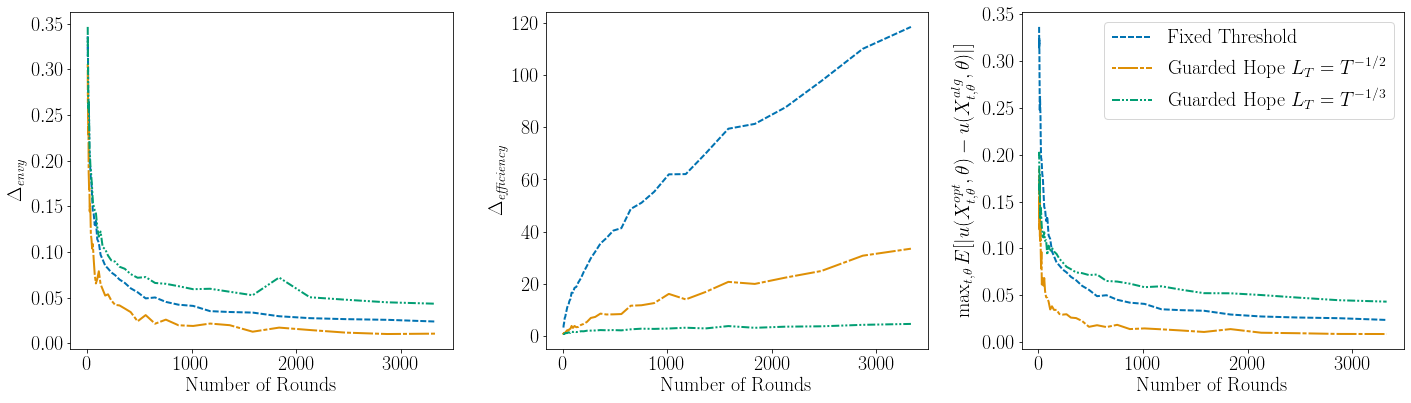

In [30]:
df = pd.DataFrame.from_records(data)

df.columns
df = df.assign(Algorithm = lambda df: df.Algorithm.replace({'fixed_threshold': 'Fixed Threshold', 'hope_guardrail_13': 'Guarded Hope $L_T = T^{-1/3}$', 'hope_guardrail_12': 'Guarded Hope $L_T = T^{-1/2}$'}))

plt.style.use('PaperDoubleFig.mplstyle.txt')
# Make some style choices for plotting 
# colorWheel =['#2bd1e5',
#             '#281bf5',
#              '#db1bf5',
#              '#F5CD1B',
#             '#FF5733','#9cf51b',]
dashesStyles = [[3,1],
            [2,1,10,1],
            [4, 1, 1, 1, 1, 1]]#,[1000,1],[8,2]]


#filled_markers = ('o', 'v', '^', '<', '>', '8', 's', 'p', '*', 'h', 'H', 'D', 'd', 'P', 'X')
#plt.figure(figsize=(20,10))
#plt.title('Simple Distribution L1')
#sns.lineplot(x='NumGroups', y='value', hue='variable', data=df[df.Norm == 'L1'])

filled_markers = ('o', 'v', '^', '<', '>', '8', 's', 'p', '*', 'h', 'H', 'D', 'd', 'P', 'X')
dash_styles = ["",
               (4, 1.5),
               (1, 1),
               (3, 1, 1.5, 1),
               (5, 1, 1, 1),
               (5, 1, 2, 1, 2, 1),
               (2, 2, 3, 1.5),
               (1, 2.5, 3, 1.2)]

# fig = plt.figure(figsize=(20,6))
plt.rc('text', usetex=True)



fg, axs = plt.subplots(1,3, sharex='all', figsize=(20,6))
sns.lineplot(x='NumGroups', y='Value', hue='Algorithm', style = 'Algorithm', dashes = dashesStyles,
                     data=df[df.Norm == 'Linf'], ax = axs[0], palette = sns.color_palette("colorblind", 3),
            ci = None)
sns.lineplot(x='NumGroups', y='Value', hue='Algorithm', style = 'Algorithm', dashes = dashesStyles, 
             data=df[df.Norm == 'Waste'], ax = axs[1], palette = sns.color_palette("colorblind", 3),
            ci = None)

sns.lineplot(x='NumGroups', y='Value', hue='Algorithm', style = 'Algorithm', dashes = dashesStyles, 
             data=df[df.Norm == 'Ex-Ante Envy'], ax = axs[2], palette = sns.color_palette("colorblind", 3),
            ci = None)



axs[0].get_legend().remove()
axs[0].set_ylabel('$\Delta_{\it envy}$')
axs[0].set_xlabel('Number of Rounds')

axs[1].set_ylabel('$\Delta_{\it efficiency}$')
axs[1].set_xlabel('Number of Rounds')
axs[1].get_legend().remove()

axs[2].get_legend().remove()
axs[2].set_ylabel(r'$\max_{t, \theta} E[|u(X^{opt}_{t, \theta}, \theta) - u(X^{alg}_{t, \theta}, \theta)|]$')
axs[2].set_xlabel('Number of Rounds')


axs[2].legend(ncol = 1, loc= 'upper right')




plt.show()
# fg.savefig('poisson.pdf', bbox_inches = 'tight',pad_inches = 0.01, dpi=900)

### Group by Group Difference

In [16]:
fair_data = []
loc_data = []
n = 500
num_iterations = 100

mean_size = 1.5
expected_size = np.zeros(n) + mean_size

for i in tqdm(range(num_iterations)):
    
    expected_size = np.zeros(n) + mean_size
    budget = n
    size = np.random.choice(size=n, a=[1.,2.], p=[1/2, 1/2])

    
    
    size_future = size[0] + np.sum(expected_size[1:])
    rem = n - 1

    lower_thresh = (budget / size_future)*(1 - (np.sqrt(cthresh*rem*np.log(rem)) / size_future) - (cthresh*np.log(rem) / size_future))
  


    opt = offline_opt(budget, size, expected_size, lower_thresh)
    for algo in algo_list:
        sol = algo(budget, size, expected_size, lower_thresh)
        
        
        
        
        for j in range(n):
            loc_data.append({'Location':j, 'Algorithm':algo.__name__, 'Value': opt[j] - sol[j]})
            
        fair_data.append({'Iteration':i, 'Algorithm':algo.__name__, 'Waste':(-1)*(budget - np.sum(sol)) / n, 'Envy':(-1)*(np.max(sol) - np.min(sol)), 
                          'Distance to OPT': (-1)*np.max(np.abs(sol-opt)), 'Proportional':(-1)* ((budget / np.sum(size)) - np.min(sol)),
                         'Nash Social Welfare': np.log(np.prod(np.power(np.asarray(sol), np.asarray(size)))) } )
            
    for i in range(n):
        loc_data.append({'Location': i, 'Algorithm':'Zero', 'Value': 0})

  0%|          | 0/100 [00:00<?, ?it/s]

[]

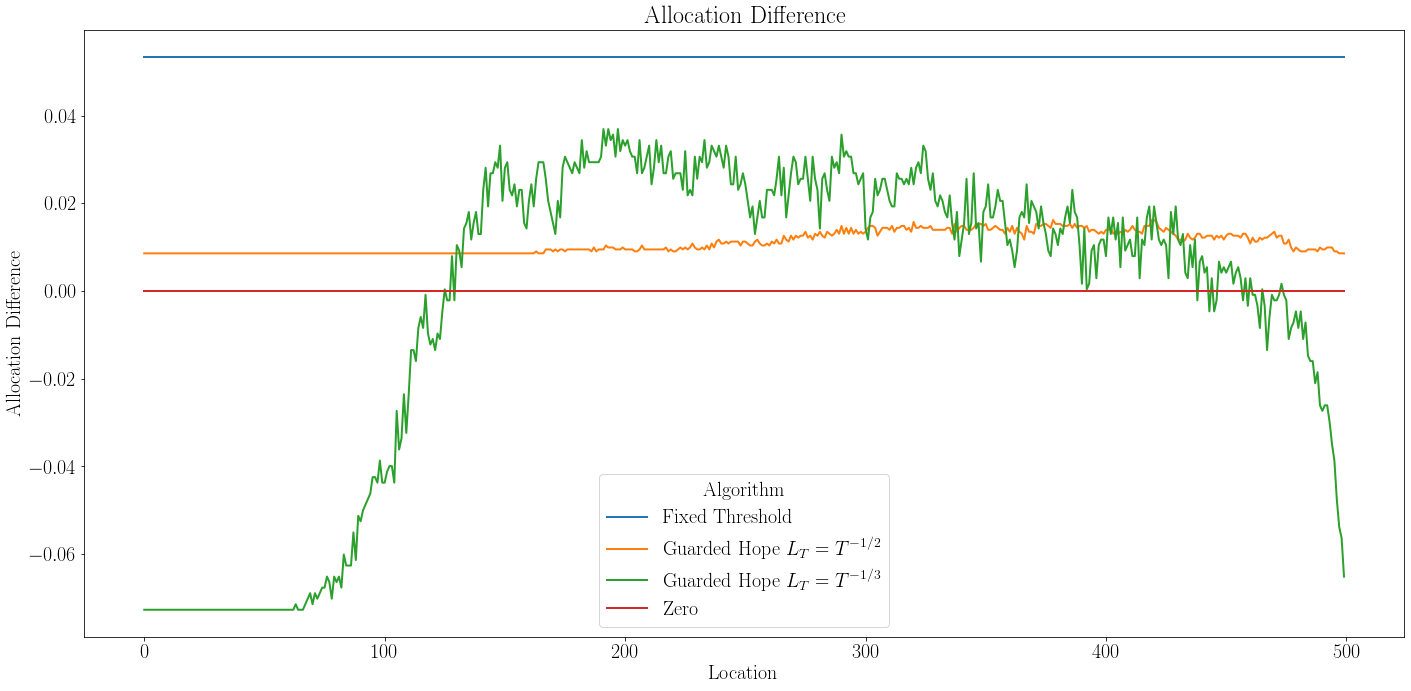

In [17]:
df = pd.DataFrame.from_records(loc_data)
df = df.assign(Algorithm = lambda df: df.Algorithm.replace({'fixed_threshold': 'Fixed Threshold', 'hope_guardrail_13': 'Guarded Hope $L_T = T^{-1/3}$', 'hope_guardrail_12': 'Guarded Hope $L_T = T^{-1/2}$'}))

plt.figure(figsize=(20,10))
sns.lineplot(x='Location', y='Value', hue = 'Algorithm', data=df, ci = None)
plt.title('Allocation Difference')
plt.xlabel('Location')
plt.ylabel('Allocation Difference')
plt.plot()

Note: Discrepancy is between where max and average are between this plot and the other one.

### Printing Fairness Metrics

In [18]:
fair_df = pd.DataFrame.from_records(fair_data)
fair_df = fair_df.assign(Algorithm = lambda df: df.Algorithm.replace({'fixed_threshold': 'Fixed Threshold', 'hope_guardrail_13': 'Guarded Hope $L_T = T^{-1/3}$', 'hope_guardrail_12': 'Guarded Hope $L_T = T^{-1/2}$'}))

fair_df = fair_df.groupby(['Algorithm']).mean()
print(fair_df.drop(['Iteration'], axis=1))

                                  Waste      Envy  Distance to OPT  \
Algorithm                                                            
Fixed Threshold               -0.388333  0.000000        -0.053321   
Guarded Hope $L_T = T^{-1/2}$ -0.346033 -0.021466        -0.030066   
Guarded Hope $L_T = T^{-1/3}$ -0.332400 -0.125992        -0.074061   

                               Proportional  Nash Social Welfare  
Algorithm                                                         
Fixed Threshold                   -0.053321          -369.673519  
Guarded Hope $L_T = T^{-1/2}$     -0.030066          -319.788190  
Guarded Hope $L_T = T^{-1/3}$     -0.053321          -313.770440  


In [19]:
def normalize(df):
    result = df.copy()
    for feature_name in df.columns:
        max_value = df[feature_name].max()
        min_value = df[feature_name].min()
        result[feature_name] = (df[feature_name] - min_value) / (max_value - min_value)
                
    return result

In [20]:
fair_df = normalize(fair_df).drop(['Iteration'], axis=1)
print(fair_df)

                                  Waste      Envy  Distance to OPT  \
Algorithm                                                            
Fixed Threshold                0.000000  1.000000         0.471406   
Guarded Hope $L_T = T^{-1/2}$  0.756249  0.829622         1.000000   
Guarded Hope $L_T = T^{-1/3}$  1.000000  0.000000         0.000000   

                               Proportional  Nash Social Welfare  
Algorithm                                                         
Fixed Threshold                         0.0             0.000000  
Guarded Hope $L_T = T^{-1/2}$           1.0             0.892354  
Guarded Hope $L_T = T^{-1/3}$           0.0             1.000000  


In [21]:
list(fair_df)

['Waste', 'Envy', 'Distance to OPT', 'Proportional', 'Nash Social Welfare']

In [22]:
from matplotlib.patches import Circle, RegularPolygon
from matplotlib.path import Path
from matplotlib.projections.polar import PolarAxes
from matplotlib.projections import register_projection
from matplotlib.spines import Spine
from matplotlib.transforms import Affine2D


def radar_factory(num_vars, frame='circle'):
    """Create a radar chart with `num_vars` axes.

    This function creates a RadarAxes projection and registers it.

    Parameters
    ----------
    num_vars : int
        Number of variables for radar chart.
    frame : {'circle' | 'polygon'}
        Shape of frame surrounding axes.

    """
    # calculate evenly-spaced axis angles
    theta = np.linspace(0, 2*np.pi, num_vars, endpoint=False)

    class RadarAxes(PolarAxes):

        name = 'radar'

        def __init__(self, *args, **kwargs):
            super().__init__(*args, **kwargs)
            # rotate plot such that the first axis is at the top
            self.set_theta_zero_location('N')

        def fill(self, *args, closed=True, **kwargs):
            """Override fill so that line is closed by default"""
            return super().fill(closed=closed, *args, **kwargs)

        def plot(self, *args, **kwargs):
            """Override plot so that line is closed by default"""
            lines = super().plot(*args, **kwargs)
            for line in lines:
                self._close_line(line)

        def _close_line(self, line):
            x, y = line.get_data()
            # FIXME: markers at x[0], y[0] get doubled-up
            if x[0] != x[-1]:
                x = np.concatenate((x, [x[0]]))
                y = np.concatenate((y, [y[0]]))
                line.set_data(x, y)

        def set_varlabels(self, labels):
            self.set_thetagrids(np.degrees(theta), labels)

        def _gen_axes_patch(self):
            # The Axes patch must be centered at (0.5, 0.5) and of radius 0.5
            # in axes coordinates.
            if frame == 'circle':
                return Circle((0.5, 0.5), 0.5)
            elif frame == 'polygon':
                return RegularPolygon((0.5, 0.5), num_vars,
                                      radius=.5, edgecolor="k")
            else:
                raise ValueError("unknown value for 'frame': %s" % frame)

        def draw(self, renderer):
            """ Draw. If frame is polygon, make gridlines polygon-shaped """
            if frame == 'polygon':
                gridlines = self.yaxis.get_gridlines()
                for gl in gridlines:
                    gl.get_path()._interpolation_steps = num_vars
            super().draw(renderer)


        def _gen_axes_spines(self):
            if frame == 'circle':
                return super()._gen_axes_spines()
            elif frame == 'polygon':
                # spine_type must be 'left'/'right'/'top'/'bottom'/'circle'.
                spine = Spine(axes=self,
                              spine_type='circle',
                              path=Path.unit_regular_polygon(num_vars))
                # unit_regular_polygon gives a polygon of radius 1 centered at
                # (0, 0) but we want a polygon of radius 0.5 centered at (0.5,
                # 0.5) in axes coordinates.
                spine.set_transform(Affine2D().scale(.5).translate(.5, .5)
                                    + self.transAxes)


                return {'polar': spine}
            else:
                raise ValueError("unknown value for 'frame': %s" % frame)

    register_projection(RadarAxes)
    return theta



In [23]:
fair_df.index

Index(['Fixed Threshold', 'Guarded Hope $L_T = T^{-1/2}$',
       'Guarded Hope $L_T = T^{-1/3}$'],
      dtype='object', name='Algorithm')

In [24]:
fair_df.iloc[0,:].to_numpy()

array([0.        , 1.        , 0.47140559, 0.        , 0.        ])

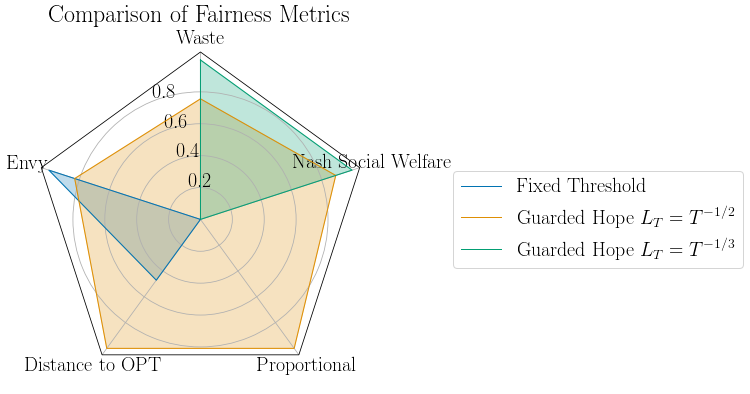

In [25]:
# number of variable


from math import pi


plt.rc('text', usetex=True)




N = len(list(fair_df))
theta = radar_factory(N, frame='polygon')

spoke_labels = list(fair_df)

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(projection='radar'))
fig.subplots_adjust(top=0.85, bottom=0.05)

ax.set_rgrids([0.2, 0.4, 0.6, 0.8])
ax.set_title('Comparison of Fairness Metrics',  position=(0.5, 1.1), ha='center')

index = 0
for algo in algo_list:
    values = fair_df.iloc[index, :].to_numpy()
    ax.plot(theta, values, linewidth=1, linestyle='solid', label=fair_df.index[index], color = sns.color_palette('colorblind', len(algo_list))[index])
    ax.fill(theta, values, color = sns.color_palette('colorblind', len(algo_list))[index],  alpha=0.25)
    index += 1
ax.set_varlabels(spoke_labels)

plt.legend(loc='right', bbox_to_anchor=(2.15, .5))

plt.show()
# plt.savefig('radar.pdf')





In [26]:
fair_df.loc(0)